## Notebook for gathering final results from UKB external validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob
import os

In [3]:
## check if folder "Results_Paper" exists, if not create it
if not os.path.exists("../Results_Paper"):
    os.makedirs("../Results_Paper")

In [ ]:
#phecodes of interest (change if wanted)
phecodes_disease_onset = ['phecode_RE_468', 'phecode_CV_404.1', 'phecode_MS_705.1', 'phecode_MS_718', 'phecode_RE_474', 'phecode_CV_431.11', 'phecode_CV_440.3', 'phecode_EM_202', 'phecode_GU_582.2', 'phecode_MB_284', 'phecode_CV_410.2', 'phecode_CV_413.11', 'phecode_CV_438.11', 'phecode_DE_664.4', 'phecode_CV_404', 'phecode_NS_324.11', 'phecode_CV_400', 'phecode_CV_413.21', 'phecode_CV_416.21', 'phecode_CV_420', 'phecode_BI_164', 'phecode_CV_401', 'phecode_CV_424']

In [ ]:
### Adapt the following parameters if necessary
max_token_length = "_8192" #in case of 4096, use "" #set to max token length based on your calculated embeddings
strategy = "auprc" # "auroc" # "auprc" #Select if auroc of auprc should be calculated
allmodels = False #False #set to True if results should be shown for all models (including LLM2Vec and Qwen2), False if only Qwen3, CLMBR and Counts
allmodelsaddition = "_allmodels" if allmodels else ""
strategy_label = "AUPRC" if strategy == "auprc" else "AUROC"

In [ ]:
indications = dict(
    disease_onset = phecodes_disease_onset,
    hospitalization = ["OMOP_9201"], #["admin_hospital"],
    death = ["OMOP_4306655"] #["admin_death"]
)
cases = ['0-1']  #['0-1', '24-10'] 
balanced = ['_balanced_'] #["_", '_balanced_']
# further cases: balanced / unbalanced

dataset = 'bigdataset' #'bigdataset' #'rawdataset' #


# Processing of tables from all different diseases

In [365]:
all_scores = []

# Calculate global min and max for y-axis
global_min = float('inf')
global_max = float('-inf')

num_cv_rounds = 10 #25

# Loop through diseases and cases to load CSVs and find min/max
for indication, phecodelist in indications.items():
    for disease in phecodelist:
        for balancedness in balanced:
            for case in cases:
                #scores_filename = f"../tables/table_{case}_{disease}_nocalcembed_*.csv"
                scores_filename = f"../tables/{indication}/table_{dataset}{max_token_length}{balancedness}gbm_dates_query_{disease}_*_runall_{num_cv_rounds}_diseaseunspecific_{case}{max_token_length}_balancedtestset_newserialization.csv"
                matching_files = glob.glob(scores_filename)
                
                if(len(matching_files) == 0):
                    print(f"Skipping {disease} {case} {balancedness}")
                    continue
                # Load the CSV#
                scores = pd.read_csv(matching_files[0])
                scores['disease'] = disease
                scores['case'] = case
                scores['balanced'] = balancedness

                columns_noaurocauprc = [c for c in scores.columns if ('auroc' not in c) and ('auprc' not in c)]

                scores_llm2vec = scores[columns_noaurocauprc + ['auroc_llm2vec'] + ['auprc_llm2vec']].copy()
                scores_llm2vec.rename(columns={'auroc_llm2vec': 'auroc', 'auprc_llm2vec': 'auprc'}, inplace=True)
                scores_llm2vec['model'] = "LLM2Vec"

                scores_qwen = scores[columns_noaurocauprc + ['auroc_qwen'] + ['auprc_qwen']].copy()
                scores_qwen.rename(columns={'auroc_qwen': 'auroc', 'auprc_qwen': 'auprc'}, inplace=True)
                scores_qwen['model'] = "Qwen"

                scores_qwen3 = scores[columns_noaurocauprc + ['auroc_qwen3'] + ['auprc_qwen3']].copy()
                scores_qwen3.rename(columns={'auroc_qwen3': 'auroc', 'auprc_qwen3': 'auprc'}, inplace=True)
                scores_qwen3['model'] = "Qwen3"

                # scores_nvembed = scores[columns_noaurocauprc + ['auroc_nvembed'] + ['auprc_nvembed']].copy()
                # scores_nvembed.rename(columns={'auroc_nvembed': 'auroc', 'auprc_nvembed': 'auprc'}, inplace=True)
                # scores_nvembed['model'] = "NVEmbed"

                scores_clmbr = scores[columns_noaurocauprc + ['auroc_clmbr'] + ['auprc_clmbr']].copy()
                scores_clmbr.rename(columns={'auroc_clmbr': 'auroc', 'auprc_clmbr': 'auprc'}, inplace=True)
                scores_clmbr['model'] = "CLMBR"

                scores_counts = scores[columns_noaurocauprc + ['auroc_counts'] + ['auprc_counts']].copy()
                scores_counts.rename(columns={'auroc_counts': 'auroc', 'auprc_counts': 'auprc'}, inplace=True)
                scores_counts['model'] = 'counts'

                # scores_agesex = scores[columns_noaurocauprc + ['auroc_agesex'] + ['auprc_agesex']].copy()
                # scores_agesex.rename(columns={'auroc_agesex': 'auroc', 'auprc_agesex': 'auprc'}, inplace=True)
                # scores_agesex['model'] = 'agesex'

                #scores = pd.concat([scores_llm2vec, scores_qwen, scores_nvembed, scores_clmbr, scores_counts])
                scores = pd.concat([scores_llm2vec, scores_qwen, scores_qwen3, scores_clmbr, scores_counts])


                all_scores.append(scores)

all_scores = pd.concat(all_scores)

#only keeps rows where crossval_iteration is between 0 and 4
all_scores = all_scores[all_scores['crossval_iteration'].isin([0, 1, 2, 3, 4])]
all_scores

,sample_size,crossval_iteration,patnum_train,testpatnum,disease,case,balanced,auroc,auprc,model
0,256,0,256,289,phecode_RE_468,0-1,_balanced_,0.708744,0.697208,LLM2Vec
1,256,1,256,289,phecode_RE_468,0-1,_balanced_,0.703787,0.697541,LLM2Vec
2,256,2,256,289,phecode_RE_468,0-1,_balanced_,0.705439,0.705005,LLM2Vec
3,256,3,256,289,phecode_RE_468,0-1,_balanced_,0.686630,0.671366,LLM2Vec
4,256,4,256,289,phecode_RE_468,0-1,_balanced_,0.734438,0.740739,LLM2Vec
...,...,...,...,...,...,...,...,...,...,...
80,1,0,1,289,OMOP_4306655,0-1,_balanced_,0.522491,0.690472,counts
81,1,1,1,289,OMOP_4306655,0-1,_balanced_,0.538062,0.698668,counts
82,1,2,1,289,OMOP_4306655,0-1,_balanced_,0.487889,0.557733,counts
83,1,3,1,289,OMOP_4306655,0-1,_balanced_,0.484429,0.557928,counts


In [366]:
all_scores.groupby(['sample_size', 'crossval_iteration', 'model'])[[strategy]].agg({
        strategy: 'mean',
    }).reset_index()

,sample_size,crossval_iteration,model,auprc
0,1,0,CLMBR,0.525012
1,1,0,LLM2Vec,0.545653
2,1,0,Qwen,0.612946
3,1,0,Qwen3,0.614853
4,1,0,counts,0.632866
...,...,...,...,...
220,256,4,CLMBR,0.681090
221,256,4,LLM2Vec,0.704009
222,256,4,Qwen,0.724577
223,256,4,Qwen3,0.732816


In [367]:
if not allmodels:
    model_name = {
        #"Qwen": "GTE-Qwen2-7B+LR",
        "Qwen3": "Qwen3-Emb-8B+LR",
        #"LLM2Vec": "LLM2Vec-Llama-3.1 8B+LR",
        "CLMBR": "CLMBR+LR",
        "counts": "Count-based+GBM",
    }
else:
    model_name = {
        "Qwen": "GTE-Qwen2-7B+LR",
        "Qwen3": "Qwen3-Emb-8B+LR",
        "LLM2Vec": "LLM2Vec-Llama-3.1 8B+LR",
        "CLMBR": "CLMBR+LR",
        "counts": "Count-based+GBM",
    }

# model_palette = {
#     "GTE-Qwen2-7B+LR": "#ad6627",           # brown
#     "Qwen3-Emb-8B+LR": "#ff7f0e",     # orange
#     "LLM2Vec-Llama-3.1 8B+LR": "#2ca02c",   # green
#     "CLMBR+LR": "#1f77b4",                  # blue
#     "Count-based+GBM": "#d62728",          # red
# }
model_palette = {
    "Qwen3-Emb-8B+LR": "#1f77b4",     # blue
    "CLMBR+LR": "#ff7f0e",                  # orange
    "Count-based+GBM": "#2ca02c",          # green
    "LLM2Vec-Llama-3.1 8B+LR": "#d62728",   # red
    "GTE-Qwen2-7B+LR": "#9467bd"           # purple
}

# Define different markers for each model
# model_markers = {
#     "CLMBR+LR": "X",
#     "Count-based+GBM": "p",
#     "GTE-Qwen2-7B+LR": "o",
#     "Qwen3-Emb-8B+LR": "o",
#     "LLM2Vec-Llama-3.1 8B+LR": "o"
# }
model_markers = {
    "Qwen3-Emb-8B+LR": "X",
    "CLMBR+LR": "o",
    "Count-based+GBM": "h",
    "LLM2Vec-Llama-3.1 8B+LR": "^", 
    "GTE-Qwen2-7B+LR": "*"      
}

task_mapping = {
    "disease_onset": "Assignment of New Diagnoses",
    "OMOP_9201": "Operational Outcomes",
    "OMOP_4306655": "Mortality Prediction",
}

selected_diseases = {"OMOP_4306655", "OMOP_9201"}

#legend_order = ["CLMBR+LR", "GTE-Qwen2-7B+LR", "Qwen3-Embedding-8B+LR", "LLM2Vec-Llama-3.1 8B+LR", "Count-based+GBM"]
if not allmodels:
    legend_order = ["Qwen3-Emb-8B+LR", "CLMBR+LR", "Count-based+GBM"]
else:
    legend_order = ["Qwen3-Emb-8B+LR", "CLMBR+LR", "Count-based+GBM", "LLM2Vec-Llama-3.1 8B+LR", "GTE-Qwen2-7B+LR"]


In [368]:
# Filter for sample size = 128
filtered_scores = all_scores[all_scores["sample_size"] == 256].copy()

# Apply mappings
filtered_scores["model"] = filtered_scores["model"].map(model_name)
filtered_scores["disease_group"] = filtered_scores["disease"].apply(
    lambda x: x if x in selected_diseases else "disease_onset"
)
filtered_scores["disease_group"] = filtered_scores["disease_group"].map(task_mapping)

# Group and calculate statistics
agg = (
    filtered_scores
    .groupby(["model", "disease_group"])[strategy]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)

# Compute 95% Confidence Interval
agg["sem"] = agg["std"] / np.sqrt(agg["count"])          # Standard Error of the Mean
agg["ci95"] = 1.96 * agg["sem"]                          # 95% CI range
agg["ci_lower"] = agg["mean"] - agg["ci95"]
agg["ci_upper"] = agg["mean"] + agg["ci95"]

# Round for readability
agg[["mean", "ci_lower", "ci_upper"]] = agg[["mean", "ci_lower", "ci_upper"]].round(3)

# Format into string: mean (lower–upper)
agg["strategy_formatted"] = agg.apply(
    lambda row: f"{row['mean']:.3f} ({row['ci_lower']:.3f}–{row['ci_upper']:.3f})", axis=1
)

# Define the desired model order based on model_name values
model_order = list(model_name.values())

# Set 'model' as a categorical type with desired order
agg["model"] = pd.Categorical(agg["model"], categories=model_order, ordered=True)

# Pivot to wide format
pretty_table = agg.pivot(index="model", columns="disease_group", values="strategy_formatted")


# Create a numerical version of the pivot table to calculate means
numerical_pivot = agg.pivot(index="model", columns="disease_group", values="mean")

# Calculate the mean across the three columns
mean_across_columns = numerical_pivot.mean(axis=1).round(3)

# Get the corresponding CI values for each task and model
ci_data = agg.pivot_table(index="model", columns="disease_group", values=["ci_lower", "ci_upper"])

# Calculate average CI boundaries
avg_ci_lower = ci_data["ci_lower"].mean(axis=1).round(3)
avg_ci_upper = ci_data["ci_upper"].mean(axis=1).round(3)

# Create the formatted string for the mean column
mean_formatted = pd.DataFrame({
    "Mean Across Tasks": [f"{mean:.3f} ({lower:.3f}–{upper:.3f})" 
                         for mean, lower, upper in zip(mean_across_columns, avg_ci_lower, avg_ci_upper)]
}, index=mean_across_columns.index)

# Join with the original table
pretty_table = pretty_table.join(mean_formatted)

# Ensure the same model order
pretty_table = pretty_table.reindex(model_order)

# Display the result
pretty_table

/tmp/ipykernel_2528881/445838349.py:50: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ci_data = agg.pivot_table(index="model", columns="disease_group", values=["ci_lower", "ci_upper"])


,Assignment of New Diagnoses,Mortality Prediction,Operational Outcomes,Mean Across Tasks
model,,,,
GTE-Qwen2-7B+LR,0.715 (0.699–0.730),0.827 (0.815–0.839),0.650 (0.640–0.659),0.731 (0.718–0.743)
Qwen3-Emb-8B+LR,0.717 (0.701–0.733),0.851 (0.836–0.866),0.661 (0.657–0.666),0.743 (0.731–0.755)
LLM2Vec-Llama-3.1 8B+LR,0.694 (0.680–0.708),0.787 (0.777–0.796),0.641 (0.637–0.644),0.707 (0.698–0.716)
CLMBR+LR,0.684 (0.668–0.699),0.803 (0.777–0.829),0.625 (0.613–0.638),0.704 (0.686–0.722)
Count-based+GBM,0.691 (0.673–0.710),0.756 (0.730–0.781),0.621 (0.611–0.630),0.689 (0.671–0.707)


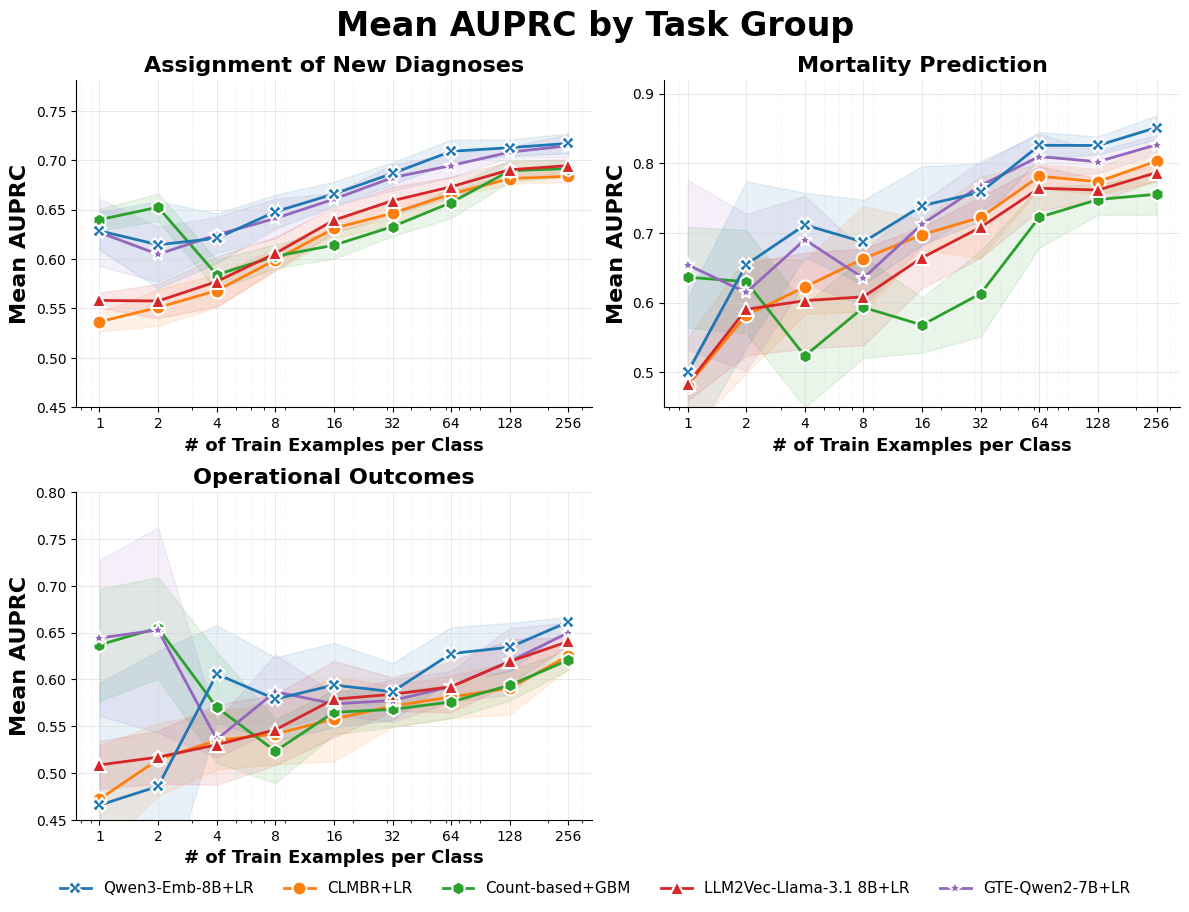

In [ ]:
all_scores["disease_group"] = all_scores["disease"].apply(
    lambda x: x if x in selected_diseases else "disease_onset"
)

# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten to easily iterate through subplots
# Add a main title
plt.suptitle("Mean " + strategy_label + " by Task Group", fontsize=24, fontweight='bold', y=0.98)
# Keep track of legend information
legend_handles = []
legend_labels = []
# Add thin gridlines to all plots as in the reference image
for ax in axes:
    ax.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)  # Horizontal lines
    ax.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)  # Vertical lines
    # Add minor grid lines (between labeled ticks) for better looks
    ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
    #Remove top and right spines, keep only left and bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    # Set y-axis limits to start at 0.45 for all plots
    ax.set_ylim(bottom=0.45)
    if ax == axes[1]:
        ax.set_ylim(bottom=0.45)

# Use all_scores directly if model_name and task_mapping aren't dictionaries
# If they are dictionaries, you can uncomment the mapping lines
all_scores_renamed = all_scores.copy()  # Create a copy for renaming

# IMPORTANT: Check if model_name and task_mapping are dictionaries before using .map()
# If not, we'll skip these steps since we don't know their structure
all_scores_renamed["model"] = all_scores_renamed["model"].map(model_name)  # Rename models
all_scores_renamed["disease_group"] = all_scores_renamed["disease_group"].map(task_mapping)  # Rename tasks

# Store data for the mean plot
task_groups = sorted(all_scores_renamed["disease_group"].unique())
mean_plot_data = {task: [] for task in task_groups}
mean_plot_iterations = {task: {} for task in task_groups}

model_lines = {}  # To store lines by model name for custom legend order
# Go through task groups and create plots for the first three subplots
for i, task in enumerate(task_groups):
    if i >= 3:  # Only create plots for first three (in case there are more than 3 groups)
        break
        
    pvt_table = all_scores_renamed[all_scores_renamed["disease_group"] == task]
    pvt_table = pvt_table.groupby(['sample_size', 'crossval_iteration', 'model'])[[strategy]].agg({
                strategy: 'mean',
            }).reset_index()
    
    # Get current axis
    ax = axes[i]
    
    # Plot mean strategy (auroc or auprc) line with markers
    for model in pvt_table['model'].unique():
        model_data = pvt_table[pvt_table['model'] == model]
        mean_data = model_data.groupby('sample_size')[strategy].agg(['mean', 'std']).reset_index()
        mean_data = mean_data.sort_values('sample_size')
        
        line = ax.plot(
            mean_data['sample_size'],
            mean_data['mean'],
            color=model_palette[model],
            marker=model_markers[model],
            markersize=10,
            label=model,
            linewidth=2,
            markeredgewidth=1.5,
            markeredgecolor='white'
        )
        # Store lines for custom ordered legend
        if model not in model_lines:
            model_lines[model] = line[0]

        # Plot shaded ±1 standard deviation region
        ax.fill_between(
            mean_data['sample_size'],
            mean_data['mean'] - mean_data['std'],
            mean_data['mean'] + mean_data['std'],
            color=model_palette[model],
            alpha=0.1
        )
        
        # Extract legend info from the first plot
        if i == 0:
            legend_handles.append(line[0])
            legend_labels.append(model)
    
    # Remove individual legend
    if ax.get_legend():
        ax.get_legend().remove()
    
    # Set x-axis to log scale
    ax.set_xscale("log")
    
    # Modify x-ticks to display integer values
    xticks = sorted(pvt_table["sample_size"].unique())
    ax.set_xticks(xticks[:-1] + [256])  # Remove "All" and add 256 for proper scaling
    ax.set_xticklabels([str(int(x)) if isinstance(x, (int, float)) else x for x in xticks])
    
    # Set title and labels
    ax.set_title(task, fontsize=16, fontweight='bold')
    ax.set_xlabel("# of Train Examples per Class", fontsize=13, fontweight='bold')
    ax.set_ylabel("Mean " + strategy_label, fontsize=16, fontweight='bold')

    # Set y-axis limits consistently
    y_max = min(1.0, pvt_table[strategy].max() + 0.05)
    ax.set_ylim(bottom=0.45, top=y_max)

axes[1].set_ylim(bottom=0.45)
fig.delaxes(axes[3])  # Remove the unused 4th subplot
# Create the legend in the desired order
ordered_handles = [model_lines[model] for model in legend_order if model in model_lines]
ordered_labels = legend_order.copy()

# Add gridlines consistent with other plots
axes[3].grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
axes[3].grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
axes[3].grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)

# Add a common legend at the bottom
plt.figlegend(
    ordered_handles,
    ordered_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=min(len(legend_labels), 5),
    frameon=False,
    fontsize=11
)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.91, bottom=0.17, hspace=0.26)
plt.savefig(f"../Results_Paper/UKB_{strategy_label}_taskgroups{allmodelsaddition}.pdf", format='pdf')
plt.savefig(f"../Results_Paper/UKB_{strategy_label}_taskgroups{allmodelsaddition}.png", format='png')
plt.show()

In [371]:
disease_mapping = {
    "OMOP_9201": ("Hospitalization"),
    "OMOP_4306655": ("Death"),
    "phecode_CV_401": ("Hypertension"),
    "phecode_EM_202": ("Diabetes mellitus"),
    "phecode_CV_416.21": ("Atrial fibrillation"),
    "phecode_RE_468": ("Pneumonia"),
    "phecode_RE_474": ("Chronic obstructive \n pulmonary disease [COPD]"),
    "phecode_GU_582.2": ("Chronic kidney disease"),
    "phecode_CV_404": ("Ischemic heart disease"),
    "phecode_CV_404.1": ("Myocardial infarction [Heart attack]"),
    "phecode_CV_431.11": ("Cerebral infarction \n [Ischemic stroke]"),
    "phecode_CV_424": ("Heart failure"),
    "phecode_CV_420": ("Cardiac arrest"),
    "phecode_CV_438.11": ("Abdominal aortic aneurysm"),
    "phecode_CV_440.3": ("Pulmonary embolism"),
    "phecode_CV_413.21": ("Aortic stenosis"),
    "phecode_CV_413.11": ("Mitral valve insufficiency"),
    "phecode_CV_410.2": ("Endocarditis"),
    "phecode_CV_400": ("Rheumatic fever and  \nchronic rheumatic heart diseases"),
    "phecode_BI_164": ("Anemia"),
    "phecode_MS_718": ("Back pain"),
    "phecode_NS_324.11": ("Parkinson's disease (Primary)"),
    "phecode_MS_705.1": ("Rheumatoid arthritis"),
    "phecode_DE_664.4": ("Psoriasis"),
    "phecode_MB_284": ("Suicide ideation and attempt  \n or self harm"),
}

/tmp/ipykernel_2528881/1358232410.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_scores_mapped["model"] = all_scores_mapped["model"].map(model_name)


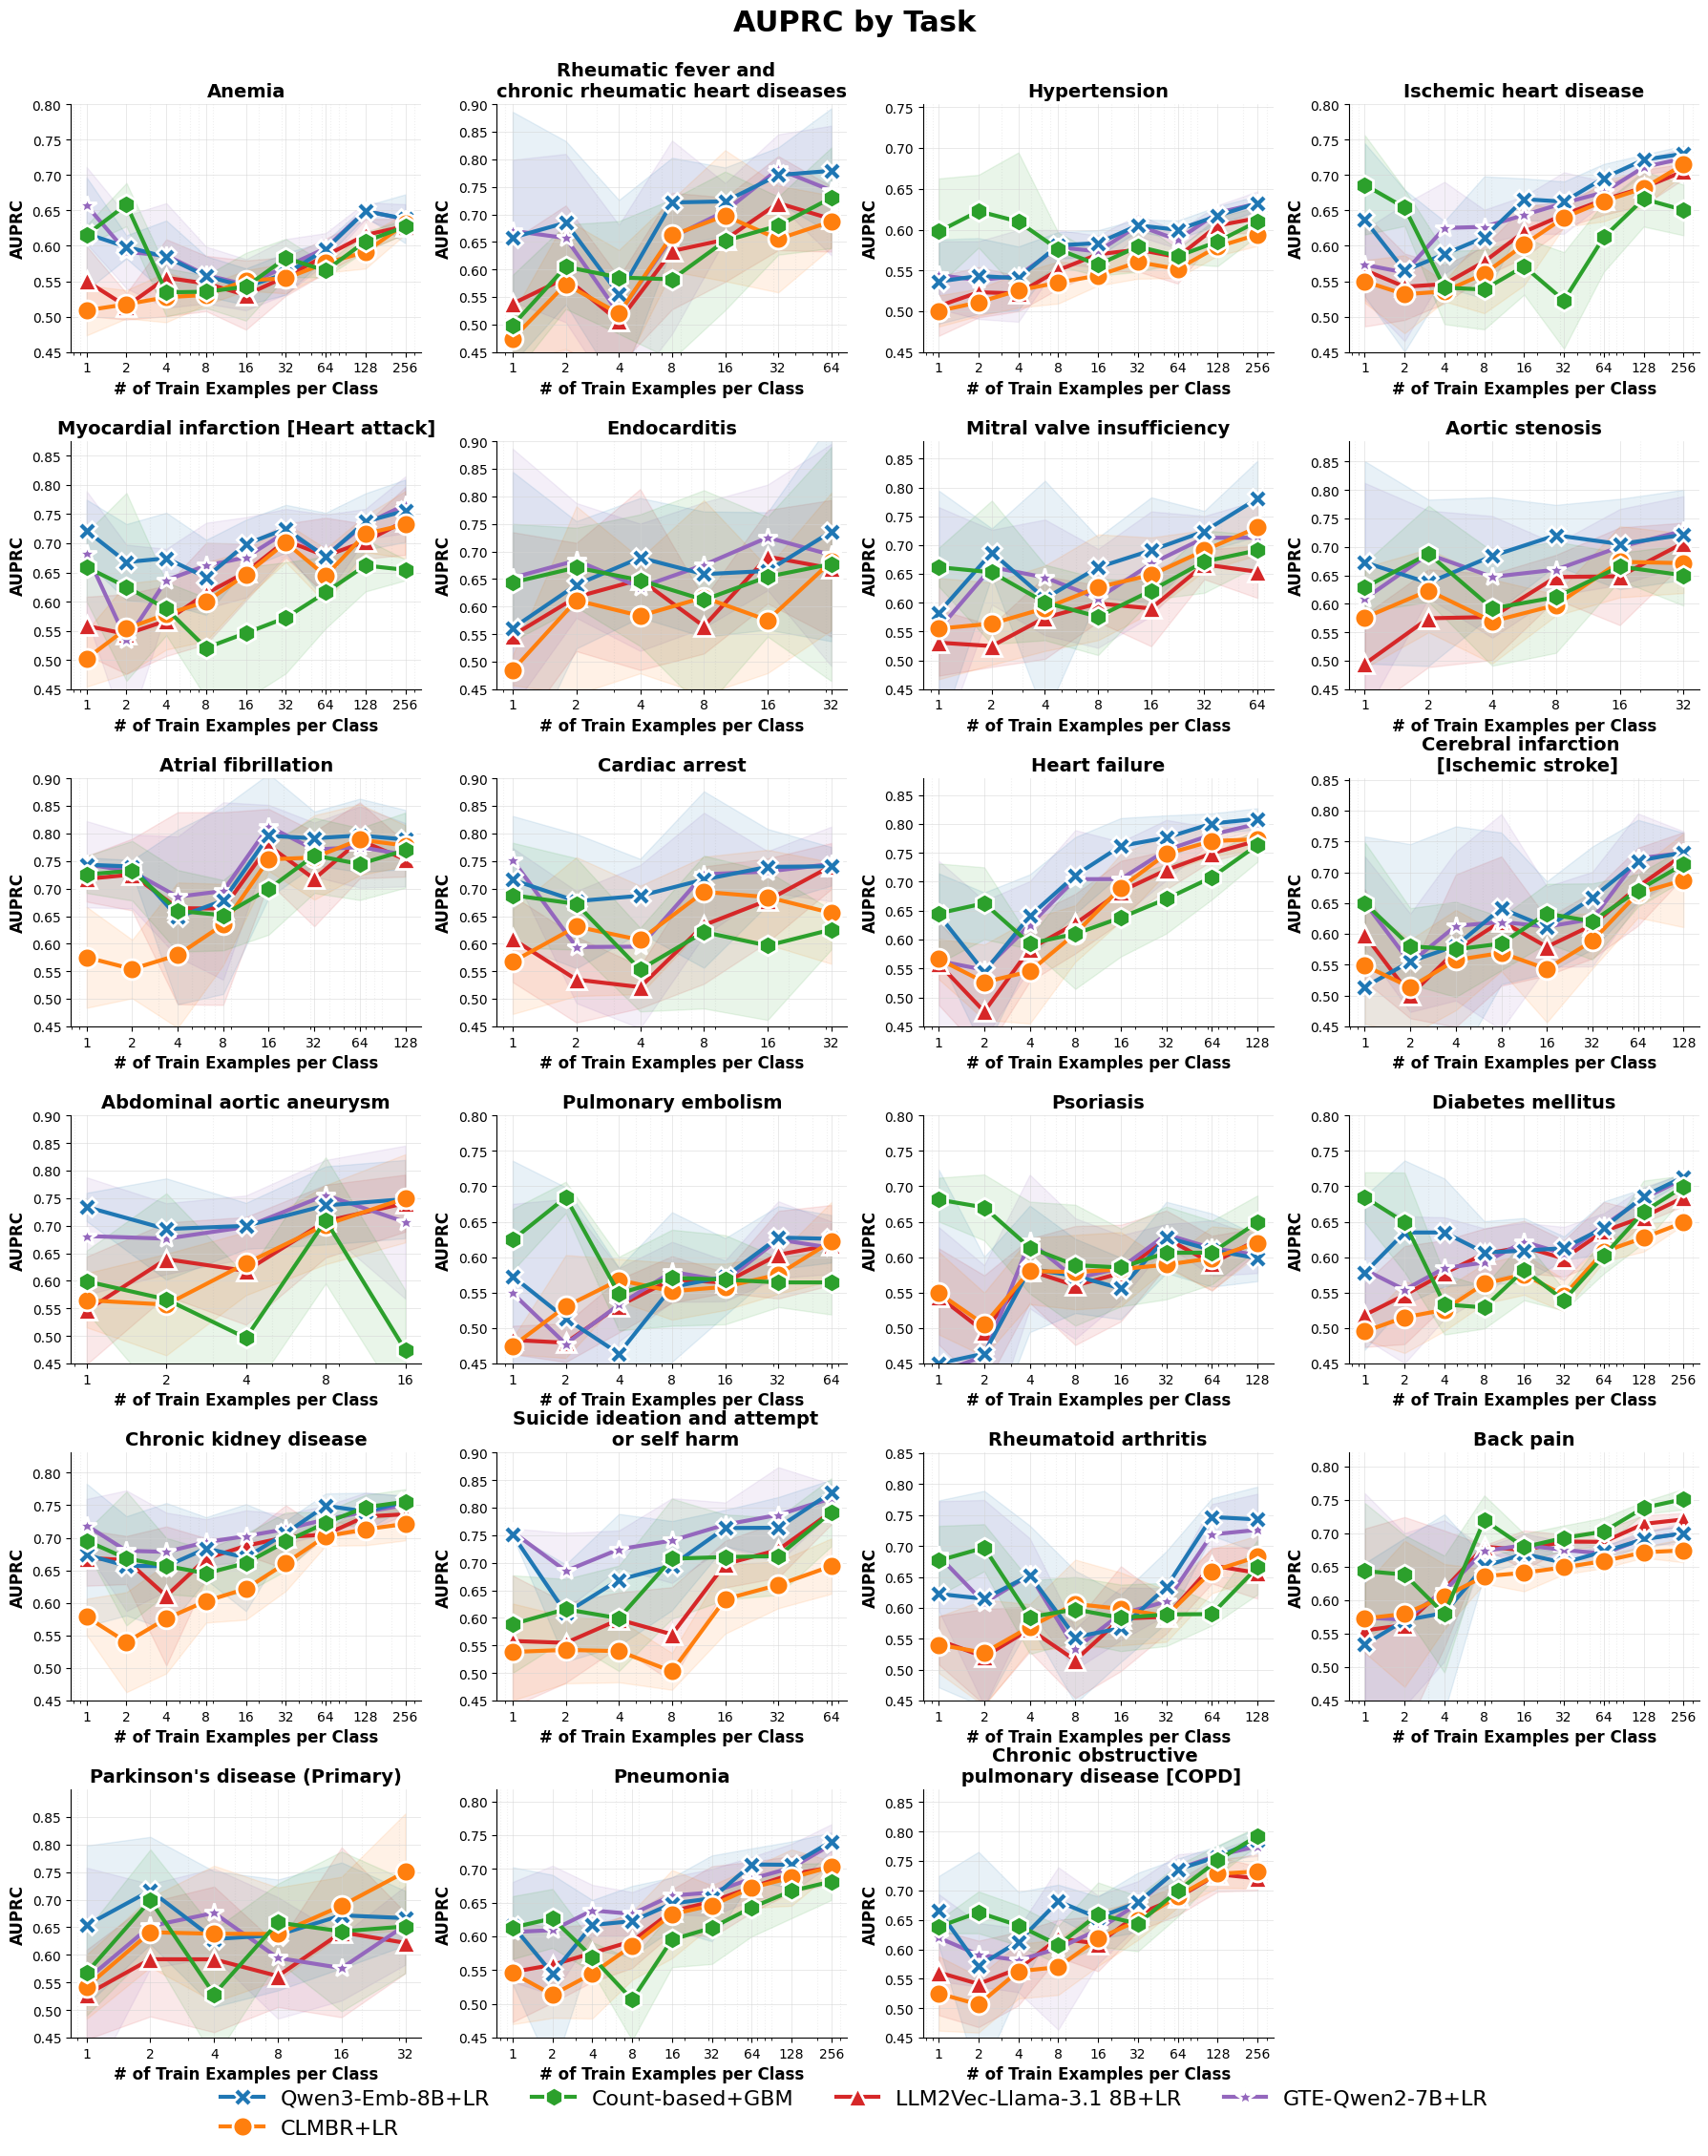

In [ ]:
# Create a figure with subplots
fig, axes = plt.subplots(6, 4, figsize=(18, 25))
axes = axes.flatten() # Flatten to easily iterate through subplots
# Add a main title
plt.suptitle(f"{strategy_label} by Task", fontsize=22, fontweight='bold', y=0.98)
# Keep track of legend information
legend_handles = []
legend_labels = []

# Apply consistent styling to all plots
for ax in axes:
    ax.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
    ax.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
    ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
    # Remove top and right spines, keep only left and bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
# Map model names
all_scores_mapped = all_scores[all_scores["disease_group"] == "disease_onset"] # Create a copy for renaming
all_scores_mapped["model"] = all_scores_mapped["model"].map(model_name)
# remove entries where model = NaN
all_scores_mapped = all_scores_mapped[all_scores_mapped["model"].notna()]

# Loop through diseases and plot
used_plots = 0
model_lines = {}  # To store lines by model name for custom legend order
for i, disease in enumerate(sorted(all_scores_mapped["disease"].unique())):
    if disease not in disease_mapping:
        continue # Skip if not in mapping
    full_name = disease_mapping[disease]
    pvt_table = all_scores_mapped[all_scores_mapped["disease"] == disease]
    # Get current axis
    ax = axes[used_plots]
    used_plots += 1
    # Plot mean strategy (auroc or auprc) line with markers for each model
    for model in pvt_table['model'].unique():
        model_data = pvt_table[pvt_table['model'] == model] #.sort_values('sample_size')
        mean_data = model_data.groupby('sample_size')[strategy].agg(['mean', 'std']).reset_index()
        mean_data = mean_data.sort_values('sample_size')
        line = ax.plot(
            mean_data['sample_size'],
            mean_data['mean'],
            color=model_palette[model],
            marker=model_markers[model], # Use custom markers for each model
            markersize=15,
            label=model,
            linewidth=3,
            markeredgewidth=2,
            markeredgecolor='white'
        )
        # Store lines for custom ordered legend
        if model not in model_lines:
            model_lines[model] = line[0]
        # Plot shaded ±1 standard deviation region
        ax.fill_between(
            mean_data['sample_size'],
            mean_data['mean'] - mean_data['std'],
            mean_data['mean'] + mean_data['std'],
            color=model_palette[model],
            alpha=0.1
        )
    # Remove individual legend
    if ax.get_legend():
        ax.get_legend().remove()
    # Set x-axis to log scale
    ax.set_xscale("log")
    # Modify x-ticks to display integer values
    xticks = sorted(pvt_table["sample_size"].unique())
    if "All" in xticks:
        xticks.remove("All")
        xticks.append("All")
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) if isinstance(x, (int, float)) else x for x in xticks])
    # Set title and labels
    ax.set_title(full_name, fontsize=14, fontweight='bold')
    ax.set_xlabel("# of Train Examples per Class", fontsize=12, fontweight='bold')
    ax.set_ylabel(strategy_label, fontsize=12, fontweight='bold')
    # Set y-axis limits based on the data
    y_min = max(0.45, pvt_table[strategy].min() - 0.05)
    y_max = min(.9, pvt_table[strategy].max() + 0.05)
    ax.set_ylim(y_min, y_max)
# Remove empty subplots
for j in range(used_plots, len(axes)):
    fig.delaxes(axes[j])
# Create the legend in the desired order
ordered_handles = [model_lines[model] for model in legend_order if model in model_lines]
ordered_labels = legend_order.copy()
# Add a common legend at the bottom with increased size
plt.figlegend(
    ordered_handles,
    ordered_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=min(len(ordered_labels), 4),
    frameon=False,
    prop={'size': 16}  # Increase legend font size
)
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.13)
plt.savefig(f"../Results_Paper/UKB_alldiseases_{strategy_label}{allmodelsaddition}.pdf", format='pdf')
plt.savefig(f"../Results_Paper/UKB_alldiseases_{strategy_label}{allmodelsaddition}.png", format='png')
plt.show()

In [373]:
all_scores.pivot_table(
    index=['disease'], 
    values=strategy, 
    columns=['model', 'case', 'balanced'], 
    aggfunc=['mean', 'std']
)

mean                                              \
model                  CLMBR    LLM2Vec       Qwen      Qwen3     counts   
case                     0-1        0-1        0-1        0-1        0-1   
balanced          _balanced_ _balanced_ _balanced_ _balanced_ _balanced_   
disease                                                                    
OMOP_4306655        0.680653   0.663254   0.723736   0.728113   0.643300   
OMOP_9201           0.554314   0.568448   0.603580   0.582191   0.589805   
phecode_BI_164      0.554277   0.564816   0.599230   0.593545   0.585253   
phecode_CV_400      0.609983   0.618336   0.676639   0.699028   0.618960   
phecode_CV_401      0.544612   0.559266   0.580393   0.582165   0.589519   
phecode_CV_404      0.608751   0.616473   0.644695   0.653072   0.604762   
phecode_CV_404.1    0.630528   0.639930   0.676362   0.699766   0.604884   
phecode_CV_410.2    0.592171   0.623061   0.677633   0.658083   0.651060   
phecode_CV_413.11   0.629424   0.591317   0.651506   0.676323   0.639217   
phecode_CV_413.21   0.618677   0.608185   0.672045   0.690246   0.639438   
phecode_CV_416.21   0.677496   0.725976   0.747102   0.747868   0.717936   
phecode_CV_420      0.639954   0.619719   0.690364   0.712773   0.626119   
phecode_CV_424      0.653754   0.646103   0.685185   0.710763   0.661347   
phecode_CV_431.11   0.584220   0.611335   0.640776   0.626382   0.628264   
phecode_CV_438.11   0.640973   0.650555   0.703494   0.722591   0.569186   
phecode_CV_440.3    0.554383   0.549631   0.563391   0.562059   0.589390   
phecode_DE_664.4    0.575694   0.575065   0.565290   0.557961   0.625146   
phecode_EM_202      0.567222   0.604181   0.619847   0.635239   0.609228   
phecode_GU_582.2    0.635221   0.686312   0.711730   0.699210   0.694083   
phecode_MB_284      0.587336   0.642024   0.754285   0.725599   0.675189   
phecode_MS_705.1    0.596301   0.580353   0.640568   0.641682   0.623123   
phecode_MS_718      0.632279   0.655792   0.650407   0.636326   0.683122   
phecode_NS_324.11   0.649870   0.589461   0.617953   0.662235   0.624686   
phecode_RE_468      0.614735   0.625582   0.659686   0.651030   0.612820   
phecode_RE_474      0.620277   0.632597   0.664028   0.682765   0.677311   

                         std                                              
model                  CLMBR    LLM2Vec       Qwen      Qwen3     counts  
case                     0-1        0-1        0-1        0-1        0-1  
balanced          _balanced_ _balanced_ _balanced_ _balanced_ _balanced_  
disease                                                                   
OMOP_4306655        0.111094   0.105186   0.096131   0.119088   0.093927  
OMOP_9201           0.053302   0.051494   0.059966   0.090773   0.052025  
phecode_BI_164      0.042881   0.048421   0.054511   0.049009   0.048541  
phecode_CV_400      0.117337   0.114670   0.141193   0.142868   0.116630  
phecode_CV_401      0.033135   0.042428   0.043018   0.042284   0.043754  
phecode_CV_404      0.073469   0.067341   0.067636   0.079652   0.075040  
phecode_CV_404.1    0.088933   0.086056   0.097575   0.064401   0.091931  
phecode_CV_410.2    0.130242   0.127357   0.142985   0.162188   0.134304  
phecode_CV_413.11   0.088606   0.068785   0.110954   0.128049   0.070315  
phecode_CV_413.21   0.073261   0.095191   0.105132   0.108723   0.074253  
phecode_CV_416.21   0.117815   0.102929   0.088885   0.103927   0.072351  
phecode_CV_420      0.097600   0.102915   0.109155   0.097341   0.102185  
phecode_CV_424      0.109095   0.107823   0.122402   0.108756   0.076350  
phecode_CV_431.11   0.085957   0.093422   0.103871   0.149472   0.071386  
phecode_CV_438.11   0.101151   0.100035   0.088614   0.063060   0.142397  
phecode_CV_440.3    0.057488   0.062349   0.100734   0.118179   0.063572  
phecode_DE_664.4    0.051755   0.067338   0.114854   0.124349   0.061804  
phecode_EM_202      0.055510   0.061351   0.071624   0.068299   0.073304  
phecode_GU_582.2  

## Create Plot comparing results of EHRShot and UKB

In [374]:
## Read in data from EHRShot task groups
chexpert_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{strategy}/chexpert_pretty.csv")
chexpert_df

,model,head,All,1,2,4,8,12,16,24,32,48,64,128
0,clmbr,lr_lbfgs,0.209,0.116,0.124,0.131,0.140,0.149,0.154,0.158,0.162,0.173,0.178,0.179
1,count,gbm,0.172,0.103,0.103,0.105,0.112,0.120,0.118,0.125,0.130,0.138,0.142,0.151
2,llm,lr_lbfgs,0.191,0.115,0.116,0.121,0.128,0.133,0.136,0.141,0.145,0.151,0.156,0.166


In [375]:
lab_values_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{strategy}/lab_values_pretty.csv")
new_diagnoses_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{strategy}/new_diagnoses_pretty.csv")
operational_outcomes_df = pd.read_csv(f"/home/sthe14/ehrshot-benchmark/EHRSHOT_ASSETS/figures/task_groups/{strategy}/operational_outcomes_pretty.csv")

In [376]:
model_name_ehrshot = {
    "llm": "Qwen3-Emb-8B+LR",
    #"llm": "GTE-Qwen2-7B+LR",
    #"llm_llama": "LLM2Vec-Llama-3.1 8B+LR",
    "clmbr": "CLMBR+LR",
    "count": "Count-based+GBM",
}

In [377]:
score_column_name = strategy
model_column_name = 'model'
sample_size_column_name = 'sample_size'
task_group_column_name = 'disease_group'

# Define the target task groups
target_tasks = ['OMOP_4306655', 'OMOP_9201', 'disease_onset']
# --- End Configuration ---


# Define the specific sample size columns required in the final output
target_sample_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
# --- End Configuration ---


# Create a dictionary to store the resulting pivot tables
result_specific_pivot_tables = {}

# Loop through each target task group
for task in target_tasks:
    # 1. Filter the original DataFrame for the current task group
    task_data = all_scores[all_scores[task_group_column_name] == task].copy()

    # Check if task_data is empty
    if task_data.empty:
        print(f"Info: No data found for task group '{task}'. Skipping.")
        continue

    # 2. Filter for the target sample sizes ONLY
    task_data_filtered = task_data[task_data[sample_size_column_name].isin(target_sample_sizes)]

    # Check if any relevant data remains
    if task_data_filtered.empty:
        print(f"Info: No data found for target sample sizes {target_sample_sizes} in task group '{task}'. Skipping.")
        continue

    # 3. Check score column validity
    if score_column_name not in task_data_filtered.columns:
        print(f"Error: Score column '{score_column_name}' not found for task group '{task}'. Skipping.")
        continue
    if not pd.api.types.is_numeric_dtype(task_data_filtered[score_column_name]):
         print(f"Error: Score column '{score_column_name}' is not numeric for task group '{task}'. Skipping.")
         continue
    # Drop rows with NaN scores before grouping
    task_data_filtered = task_data_filtered.dropna(subset=[score_column_name])
    if task_data_filtered.empty:
        print(f"Info: No non-NaN scores found for target sample sizes in task group '{task}'. Skipping.")
        continue


    # 4. Calculate mean score per model and relevant sample size
    mean_per_target_sample = task_data_filtered.groupby(
            [model_column_name, sample_size_column_name]
        )[score_column_name].mean()

    # Check if aggregation yielded results
    if mean_per_target_sample.empty:
         print(f"Info: Aggregation yielded no results for task group '{task}'. Skipping.")
         continue

    # 5. Pivot using unstack to get sample sizes as columns
    # The index will be 'model' at this stage
    pivoted_data = mean_per_target_sample.unstack(level=sample_size_column_name)

    # 6. Ensure all target sample size columns exist in the desired order
    # Use .reindex() to add missing columns (filled with NaN) and order them
    pivoted_data = pivoted_data.reindex(columns=target_sample_sizes)

    # 7. Reset index to move 'model' from the index to the first column
    final_table = pivoted_data.reset_index()

    # 8. Clean up the name of the columns axis (optional aesthetic step)
    final_table.columns.name = None

    # Store the final table
    result_specific_pivot_tables[task] = final_table

In [378]:
death_df = result_specific_pivot_tables["OMOP_4306655"]
hospitalization_df = result_specific_pivot_tables["OMOP_9201"]
disease_onset_df = result_specific_pivot_tables["disease_onset"]

In [379]:
hospitalization_df

,model,1,2,4,8,16,32,64,128,256
0,CLMBR,0.471896,0.514341,0.534759,0.541605,0.557604,0.571368,0.581295,0.590543,0.625415
1,LLM2Vec,0.508492,0.516844,0.530037,0.546052,0.578817,0.584019,0.592103,0.619106,0.640557
2,Qwen,0.644219,0.652746,0.535825,0.586728,0.573859,0.577307,0.592409,0.619261,0.649864
3,Qwen3,0.465484,0.485647,0.605571,0.578897,0.593856,0.586835,0.627578,0.634359,0.661493
4,counts,0.636881,0.655014,0.570119,0.523263,0.564816,0.567840,0.575902,0.593717,0.620690


In [380]:
death_df

,model,1,2,4,8,16,32,64,128,256
0,CLMBR,0.480886,0.581725,0.622445,0.663046,0.697483,0.722345,0.781321,0.773566,0.803062
1,LLM2Vec,0.482951,0.590297,0.602767,0.608305,0.664472,0.708174,0.764136,0.761549,0.786634
2,Qwen,0.654281,0.614496,0.690320,0.635280,0.712645,0.768070,0.809682,0.802191,0.826660
3,Qwen3,0.499738,0.654568,0.711471,0.686960,0.739189,0.758436,0.825816,0.825536,0.851303
4,counts,0.636408,0.630084,0.523371,0.593102,0.567802,0.612893,0.722536,0.747970,0.755533


In [381]:
disease_onset_df

,model,1,2,4,8,16,32,64,128,256
0,CLMBR,0.536379,0.550804,0.567882,0.598986,0.630928,0.646303,0.665761,0.681264,0.683669
1,LLM2Vec,0.557984,0.557357,0.577034,0.605551,0.639211,0.658977,0.673031,0.690264,0.694425
2,Qwen,0.626794,0.604680,0.624374,0.640946,0.660520,0.682315,0.694504,0.708126,0.714556
3,Qwen3,0.628438,0.614357,0.620850,0.647799,0.665743,0.686564,0.708904,0.712652,0.716916
4,counts,0.639751,0.652317,0.583968,0.602672,0.613858,0.632725,0.657077,0.689215,0.691448


In [382]:
death_df.columns = death_df.columns.astype(str)
hospitalization_df.columns = hospitalization_df.columns.astype(str)
disease_onset_df.columns = disease_onset_df.columns.astype(str)

In [383]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have all eight dataframes loaded:
# chexpert_df, lab_values_df, new_diagnoses_df, operational_outcomes_df
# one_df, two_df, three_df, four_df

# Lists of the original and new dataframes
original_dfs = [chexpert_df, lab_values_df, new_diagnoses_df, operational_outcomes_df]
original_names = ["chexpert", "lab_values", "new_diagnoses", "operational_outcomes"]
new_dfs = [death_df, hospitalization_df, disease_onset_df]
## remove rows of dfs in new_dfs where model == NaN
new_dfs = [df[df['model'].notna()] for df in new_dfs]

new_names = ["death", "hospitalization", "disease_onset"]
for i, df in enumerate(original_dfs):
    df["model"] = df["model"].map(model_name_ehrshot)
for i, df in enumerate(new_dfs):
    df["model"] = df["model"].map(model_name)

# Define the columns for sample sizes
sample_cols_ehrshot = ['1', '2', '4', '8', '16', '32', '64', '128', 'All'] #['1', '2', '4', '8', '12', '16', '24', '32', '48', '64', '128', 'All']


In [384]:
new_dfs = [df[df['model'].notna()] for df in new_dfs]

In [385]:
## In original df's, change column name from 'All' to 256
for df in original_dfs:
    if 'All' in df.columns:
        df.rename(columns={'All': '256'}, inplace=True)

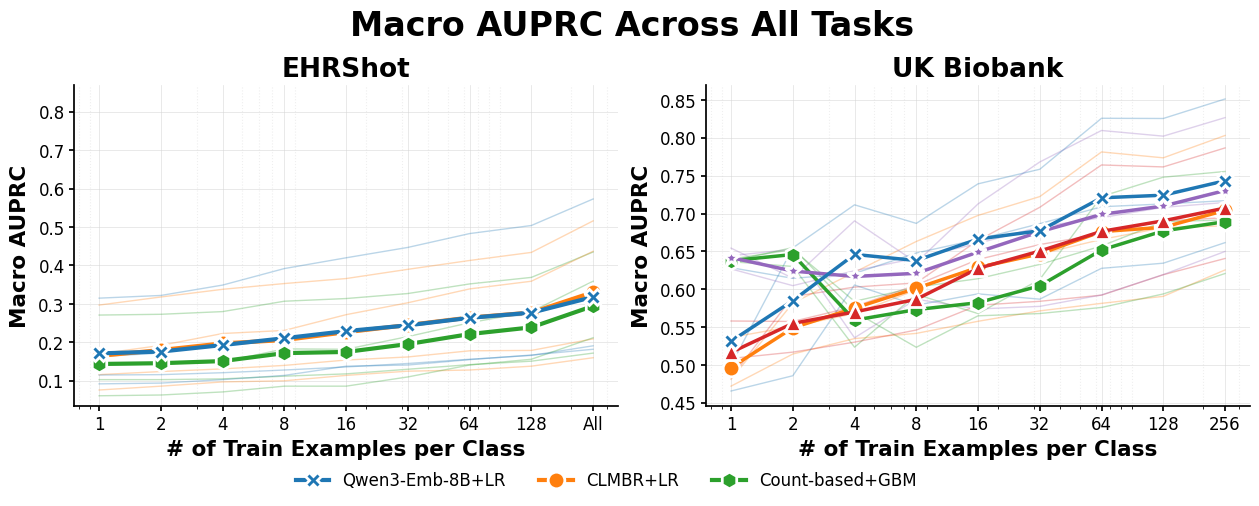

In [ ]:
# Create a 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes = axes.flatten()  # Flatten to easily iterate through subplots

fig.tight_layout(rect=[0.035, 0.12, 0.995, 0.88], w_pad=3.3)  # leave space for suptitle and legend

# Add a main title
fig.suptitle(f"Macro {strategy_label} Across All Tasks", fontsize=24, fontweight='bold', y=0.99)

# Apply consistent styling to all plots
for ax in axes:
    ax.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
    ax.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
    ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
    # Remove top and right spines, keep only left and bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# --- Plot for the original dataframes (first subplot) ---
ax1 = axes[0]

# Define the standard sample sizes we want to display (powers of 2)
standard_sample_sizes_ehrshot = ['1', '2', '4', '8', '16', '32', '64', '128', '256']
standard_sample_sizes_ukb = ['1', '2', '4', '8', '16', '32', '64', '128', '256']

# Sample columns with numeric values for proper log scale - only include standard sizes
sample_cols_ehrshot = []
for df in original_dfs:
    sample_cols_ehrshot.extend([col for col in df.columns if col in standard_sample_sizes_ehrshot])
sample_cols_ehrshot = sorted(list(set(sample_cols_ehrshot)), key=lambda x: int(x) if x.isdigit() else 0)
numeric_sample_cols = [int(col) for col in sample_cols_ehrshot]

# Plot the blurred lines for each individual dataframe
for i, df in enumerate(original_dfs):
    model_names = df['model'].unique()
    for model in model_names:
        model_df = df[df['model'] == model]
        # Only use columns that exist in this DataFrame
        valid_cols = [col for col in sample_cols_ehrshot if col in model_df.columns]
        performance = model_df[valid_cols].values.flatten()
        # Use numeric x values for proper log scale - only for columns that exist
        valid_numeric_cols = [int(col) for col in valid_cols]
        x_vals = np.repeat(valid_numeric_cols, len(model_df))
        sns.lineplot(
            x=x_vals, 
            y=performance, 
            ax=ax1, 
            alpha=0.3, 
            label=f'_{original_names[i]}_{model}', 
            linewidth=1,
            color=model_palette[model]
        )

# Calculate the mean performance across all original tasks
all_original_data = pd.concat(original_dfs)
mean_performance_original = all_original_data.groupby('model')[sample_cols_ehrshot].mean()

# Plot the mean lines for the original data
for model in mean_performance_original.index:
    ax1.plot(
        numeric_sample_cols,  # Use numeric values for x
        mean_performance_original.loc[model],
        color=model_palette[model],
        marker=model_markers[model],
        markersize=12,
        linewidth=3,
        label=model,
        markeredgewidth=2,
        markeredgecolor='white'
    )

# Set the aesthetics for the first subplot
ax1.set_xscale("log")
ax1.set_xticks(numeric_sample_cols)  # Set the tick positions to our exact numeric values
#ax1.set_xticklabels(sample_cols_ehrshot)  # Use string labels for the ticks
ehrshot_labels = ['All' if x == '256' else x for x in sample_cols_ehrshot]
ax1.set_xticklabels(ehrshot_labels)
ax1.set_xlabel("# of Train Examples per Class", fontsize=15.5, fontweight='bold')
ax1.set_ylabel("Macro " + strategy_label, fontsize=15.5, fontweight='bold', labelpad=6)
ax1.set_title("EHRShot", fontsize=19, fontweight='bold')
ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax1.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
# Add minor grid lines (between labeled ticks) for better looks
ax1.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.25)  # x-axis
ax1.spines['left'].set_linewidth(1.25)    # y-axis
ax1.tick_params(axis='both', labelsize=12, width=1.25)
ax1.set_ylim(top=0.87)

# --- Plot for the UKB dataframes (second subplot) ---
ax2 = axes[1]

# Define the columns for sample sizes - using the same standard sizes for UKB
sample_cols_ukb = []
for df in new_dfs:
    sample_cols_ukb.extend([col for col in df.columns if col in standard_sample_sizes_ukb])
sample_cols_ukb = sorted(list(set(sample_cols_ukb)), key=lambda x: int(x) if x.isdigit() else 0)
numeric_sample_cols_ukb = [int(col) for col in sample_cols_ukb]

# Plot the blurred lines for each individual dataframe
for i, df in enumerate(new_dfs):
    model_names = df['model'].unique()
    for model in model_names:
        model_df = df[df['model'] == model]
        # Only use columns that exist in this DataFrame
        valid_cols = [col for col in sample_cols_ukb if col in model_df.columns]
        performance = model_df[valid_cols].values.flatten()
        # Use numeric x values for proper log scale - only for columns that exist
        valid_numeric_cols = [int(col) for col in valid_cols]
        x_vals = np.repeat(valid_numeric_cols, len(model_df))
        sns.lineplot(
            x=x_vals, 
            y=performance, 
            ax=ax2, 
            alpha=0.3, 
            label=f'_{new_names[i]}_{model}', 
            linewidth=1,
            color=model_palette[model],
        )

# Calculate the mean performance across all new tasks
all_new_data = pd.concat(new_dfs)
mean_performance_new = all_new_data.groupby('model')[sample_cols_ukb].mean()

# Plot the mean lines for UKB data
for model in mean_performance_new.index:
    ax2.plot(
        numeric_sample_cols_ukb,  # Use numeric values for x
        mean_performance_new.loc[model],
        color=model_palette[model],
        marker=model_markers[model],
        markersize=12,
        linewidth=2.5,
        label=model,
        markeredgewidth=2,
        markeredgecolor='white'
    )

# Set the aesthetics for the second subplot
ax2.set_xscale("log")
ax2.set_xticks(numeric_sample_cols_ukb)  # Set the tick positions to our exact numeric values
ax2.set_xticklabels(sample_cols_ukb)  # Use string labels for the ticks
ax2.set_xlabel("# of Train Examples per Class", fontsize=15.5, fontweight='bold')
ax2.set_ylabel("Macro " + strategy_label, fontsize=15.5, fontweight='bold', labelpad=6)
ax2.set_title("UK Biobank", fontsize=19, fontweight='bold')
ax2.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax2.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax2.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_linewidth(1.25)  # x-axis
ax2.spines['left'].set_linewidth(1.25)    # y-axis
ax2.tick_params(axis='both', labelsize=12, width=1.25)
ax2.set_ylim(top=0.87)

# Create a common legend below the plot
handles = [plt.Line2D([0], [0], marker=model_markers[model], color=model_palette[model], linestyle='-', markersize=12, linewidth=3, markeredgewidth=2, markeredgecolor='white') for model in legend_order if model in model_palette and model in mean_performance_original.index and model in mean_performance_new.index]
labels = [model for model in legend_order if model in model_palette and model in mean_performance_original.index and model in mean_performance_new.index]

plt.figlegend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.48, 0), 
    ncol=len(labels), 
    frameon=False, 
    fontsize=12,
    prop={'size': 12}  # Increase legend font size
)

# Save the figure
plt.savefig(f"../Results_Paper/EHRShot_UKB_alltasks_{strategy_label}.pdf", format='pdf')
plt.savefig(f"../Results_Paper/EHRShot_UKB_alltasks_{strategy_label}.png", format='png')
plt.show()

In [ ]:

# # Create a 1x2 figure
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# axes = axes.flatten()  # Flatten to easily iterate through subplots

# fig.tight_layout(rect=[0.035, 0.12, 0.995, 0.88], w_pad=3.25)  # leave space for suptitle and legend

# # Add a main title
# fig.suptitle(f"Mean {strategy_label} Across All Tasks", fontsize=24, fontweight='bold', y=0.99)

# # Apply consistent styling to all plots
# for ax in axes:
#     ax.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
#     ax.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
#     ax.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
#     # Remove top and right spines, keep only left and bottom
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['left'].set_visible(True)
#     ax.spines['bottom'].set_visible(True)



# # --- Plot for the original dataframes (first subplot) ---
# ax1 = axes[0]

# # Plot the blurred lines for each individual dataframe
# for i, df in enumerate(original_dfs):
#     #df["model"] = df["model"].map(model_name_ehrshot)
#     model_names = df['model'].unique()
#     for model in model_names:
#         model_df = df[df['model'] == model]
#         performance = model_df[sample_cols_ehrshot].values.flatten()
#         x_vals = list(range(len(sample_cols_ehrshot))) * len(model_df)
#         sns.lineplot(
#             x=x_vals, 
#             y=performance, 
#             ax=ax1, 
#             alpha=0.3, 
#             label=f'_{original_names[i]}_{model}', 
#             linewidth=1,
#             color=model_palette[model]
#         )

# # Calculate the mean performance across all original tasks
# all_original_data = pd.concat(original_dfs)

# #all_original_data["model"] = all_original_data["model"].map(model_name_ehrshot)

# mean_performance_original = all_original_data.groupby('model')[sample_cols_ehrshot].mean()

# # Plot the mean lines for the original data
# for model in mean_performance_original.index:
#     ax1.plot(
#         mean_performance_original.columns,
#         mean_performance_original.loc[model],
#         color=model_palette[model],
#         marker=model_markers[model],
#         markersize=12,
#         linewidth=3,
#         label=model,
#         markeredgewidth=2,
#         markeredgecolor='white'
#     )

# # Set the aesthetics for the first subplot
# ax1.set_xticks(range(len(sample_cols_ehrshot)))
# ax1.set_xticklabels(sample_cols_ehrshot)
# ax1.set_xlabel("# of Train Examples per Class", fontsize=15.5, fontweight='bold')
# ax1.set_ylabel(strategy_label, fontsize=15.5, fontweight='bold', labelpad=6)
# ax1.set_title("EHRShot", fontsize=19, fontweight='bold')
# ax1.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
# ax1.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)    # Add minor grid lines (between labeled ticks) for better looks
# ax1.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
# ax1.tick_params(axis='both', labelsize=12)  # adjust the font size as needed
# ax1.set_ylim(top=0.87)


# # --- Plot for the UKB dataframes (second subplot) ---
# ax2 = axes[1]

# # Define the columns for sample sizes
# sample_cols_ukb = ['1', '2', '4', '8', '16', '32', '64', '128', '256']

# # Plot the blurred lines for each individual dataframe
# for i, df in enumerate(new_dfs):
#     #df["model"] = df["model"].map(model_name)
#     model_names = df['model'].unique()
#     for model in model_names:
#         model_df = df[df['model'] == model]
#         performance = model_df[sample_cols_ukb].values.flatten()
#         x_vals = list(range(len(sample_cols_ukb))) * len(model_df)
#         sns.lineplot(
#             x=x_vals, 
#             y=performance, 
#             ax=ax2, 
#             alpha=0.3, 
#             label=f'_{new_names[i]}_{model}', 
#             linewidth=1,
#             color=model_palette[model],
#         )

# # Calculate the mean performance across all new tasks
# all_new_data = pd.concat(new_dfs)

# #all_new_data["model"] = all_new_data["model"].map(model_name)
# mean_performance_new = all_new_data.groupby('model')[sample_cols_ukb].mean()

# # Plot the mean lines for UKB data
# for model in mean_performance_new.index:
#     ax2.plot(
#         mean_performance_new.columns,
#         mean_performance_new.loc[model],
#         color=model_palette[model],
#         marker=model_markers[model],
#         markersize=12,
#         linewidth=3,
#         label=model,
#         markeredgewidth=2,
#         markeredgecolor='white'
#     )

# # Set the aesthetics for the second subplot
# ax2.set_xticks(range(len(sample_cols_ukb)))
# ax2.set_xticklabels(sample_cols_ukb)
# ax2.set_xlabel("# of Train Examples per Class", fontsize=15.5, fontweight='bold')
# ax2.set_ylabel(strategy_label, fontsize=15.5, fontweight='bold', labelpad=6)
# ax2.set_title("UK Biobank", fontsize=19, fontweight='bold')
# ax2.grid(True, axis='y', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
# ax2.grid(True, axis='x', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
# ax2.grid(True, which='minor', axis='x', linestyle=':', alpha=0.2)
# ax2.spines['top'].set_visible(False)
# ax2.spines['right'].set_visible(False)
# ax2.tick_params(axis='both', labelsize=12)
# ax2.set_ylim(top=0.87)

# # Create a common legend below the plot
# handles = [plt.Line2D([0], [0], marker=model_markers[model], color=model_palette[model], linestyle='-', markersize=12, linewidth=3, markeredgewidth=2, markeredgecolor='white') for model in legend_order if model in model_palette and model in mean_performance_original.index and model in mean_performance_new.index]
# labels = [model for model in legend_order if model in model_palette and model in mean_performance_original.index and model in mean_performance_new.index]

# plt.figlegend(
#     handles, 
#     labels, 
#     loc='lower center', 
#     bbox_to_anchor=(0.48, 0), 
#     ncol=len(labels), 
#     frameon=False, 
#     fontsize=12,
#     prop={'size': 12}  # Increase legend font size
# )

# # Adjust layout to prevent overlapping titles/labels
# #plt.tight_layout() # Adjust bottom for the legend

# #plt.subplots_adjust(top=0.9, bottom=0.05)
# plt.savefig(f"../Results_Paper/EHRShot_UKB_alltasks_{strategy_label}.pdf", format='pdf')
# plt.savefig(f"../Results_Paper/EHRShot_UKB_alltasks_{strategy_label}.png", format='png')
# plt.show()